# 03 — Exploratory Data Analysis (revised)

This notebook uses the **cleaned outputs** from `02_data_cleaning_reordered_final.ipynb`.
The purpose of the EDA is deliberately narrow: it should help the reader see the
spatial problem before the demand-estimation and optimisation chapters.

The logic is:

1. **Where is the baseline demand?**  
   Household vehicle stock shows where households are most likely to generate charging demand.

2. **Where is disadvantage concentrated?**  
   The Income Domain score identifies which LSOAs should receive greater equity weight.

3. **Where is the existing on-street provision?**  
   Existing charging locations (`e_i`) show how infrastructure is currently distributed.

4. **Where is the existing provision under pressure?**  
   Mean location utilisation (`U_i`) shows whether existing supply appears lightly used,
   heavily used, or absent altogether.

Taken together, the four panels are meant to establish a visual intuition:
**existing provision does not necessarily align with either baseline demand or equity priorities.**
The formal modelling chapters will quantify that intuition.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

BASE = Path("/Users/alexia/Documents/CASA/Dissertation")
PROCESSED_DIR = BASE / "05_processed"
FIGURES_DIR = BASE / "06_figures/eda"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PATHS = {
    "census": PROCESSED_DIR / "census_london_clean.csv",
    "imd": PROCESSED_DIR / "imd_london_clean.csv",
    "location_lsoa": PROCESSED_DIR / "location_lsoa_clean.csv",
    "location_utilisation": PROCESSED_DIR / "location_utilisation_clean.csv",
    "lsoa_supply": PROCESSED_DIR / "lsoa_supply_clean.csv",
    "lsoa_boundaries": BASE / "03_data/demand/spatial/LSOA_2021_EW_BGC_V5.shp",
}

for name, path in PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {name}: {path}")

pd.set_option("display.max_columns", 100)
print("Processed data directory:", PROCESSED_DIR)
print("Figures directory:", FIGURES_DIR)


Processed data directory: /Users/alexia/Documents/CASA/Dissertation/05_processed
Figures directory: /Users/alexia/Documents/CASA/Dissertation/06_figures/eda


## 1. Load cleaned datasets and build the LSOA analytical file

Only cleaned, location-consistent outputs are used here.  
This avoids re-running cleaning logic inside the EDA notebook.


In [2]:
census = pd.read_csv(PATHS["census"])
imd = pd.read_csv(PATHS["imd"])
location_lsoa = pd.read_csv(PATHS["location_lsoa"])
location_utilisation = pd.read_csv(PATHS["location_utilisation"])
lsoa_supply = pd.read_csv(PATHS["lsoa_supply"])

lsoa_boundaries = gpd.read_file(PATHS["lsoa_boundaries"])
if lsoa_boundaries.crs is None:
    raise ValueError("Boundary file has no CRS.")
lsoa_boundaries = lsoa_boundaries.to_crs(epsg=27700)

# Keep only Greater London LSOAs found in the cleaned Census file.
london_codes = set(census["lsoa_code"])
lsoa_gdf = (
    lsoa_boundaries.loc[
        lsoa_boundaries["LSOA21CD"].isin(london_codes),
        ["LSOA21CD", "geometry"]
    ]
    .rename(columns={"LSOA21CD": "lsoa_code"})
    .copy()
)

# Merge the four principal inputs.
lsoa_gdf = (
    lsoa_gdf.merge(
        census[["lsoa_code", "lsoa_name", "Hi", "Ci", "vehicle_stock_proxy"]],
        on="lsoa_code",
        how="left",
        validate="one_to_one",
    )
    .merge(
        imd[["lsoa_code", "income_score", "income_decile"]],
        on="lsoa_code",
        how="left",
        validate="one_to_one",
    )
    .merge(
        lsoa_supply[
            ["lsoa_code", "e_i", "S_eff_i", "U_i", "has_evse_i",
             "n_evse", "n_active_evse", "n_active_locations"]
        ],
        on="lsoa_code",
        how="left",
        validate="one_to_one",
    )
)

if len(lsoa_gdf) != 4_994:
    warnings.warn(f"Expected 4,994 London LSOAs, found {len(lsoa_gdf):,}.")

# EDA-specific status variable for Panel D and summary tables.
lsoa_gdf["utilisation_status"] = np.select(
    [
        ~lsoa_gdf["has_evse_i"],
        lsoa_gdf["has_evse_i"] & lsoa_gdf["U_i"].fillna(0).eq(0),
        lsoa_gdf["has_evse_i"] & lsoa_gdf["U_i"].fillna(0).gt(0),
    ],
    [
        "No on-street provision",
        "On-street provision but zero observed utilisation",
        "On-street provision with positive observed utilisation",
    ],
    default="Unclassified",
)

print("LSOA analytical file shape:", lsoa_gdf.shape)
print("Missing values by core variable:")
display(
    lsoa_gdf[
        ["vehicle_stock_proxy", "income_score", "e_i", "U_i", "has_evse_i"]
    ].isna().sum().to_frame("missing_count")
)


LSOA analytical file shape: (4994, 16)
Missing values by core variable:


,missing_count
vehicle_stock_proxy,0
income_score,0
e_i,0
U_i,1837
has_evse_i,0


## 2. Descriptive summaries

These are not the main result.  
They simply confirm that the cleaned variables look sensible before mapping.


In [3]:
core_summary = pd.DataFrame(
    {
        "variable": [
            "Household vehicle stock proxy",
            "Income deprivation score",
            "Existing on-street locations (e_i)",
            "Location-equivalent effective supply (S_eff_i)",
            "Mean location utilisation (U_i, where e_i > 0)",
        ],
        "min": [
            lsoa_gdf["vehicle_stock_proxy"].min(),
            lsoa_gdf["income_score"].min(),
            lsoa_gdf["e_i"].min(),
            lsoa_gdf["S_eff_i"].min(),
            lsoa_gdf.loc[lsoa_gdf["has_evse_i"], "U_i"].min(),
        ],
        "median": [
            lsoa_gdf["vehicle_stock_proxy"].median(),
            lsoa_gdf["income_score"].median(),
            lsoa_gdf["e_i"].median(),
            lsoa_gdf["S_eff_i"].median(),
            lsoa_gdf.loc[lsoa_gdf["has_evse_i"], "U_i"].median(),
        ],
        "mean": [
            lsoa_gdf["vehicle_stock_proxy"].mean(),
            lsoa_gdf["income_score"].mean(),
            lsoa_gdf["e_i"].mean(),
            lsoa_gdf["S_eff_i"].mean(),
            lsoa_gdf.loc[lsoa_gdf["has_evse_i"], "U_i"].mean(),
        ],
        "max": [
            lsoa_gdf["vehicle_stock_proxy"].max(),
            lsoa_gdf["income_score"].max(),
            lsoa_gdf["e_i"].max(),
            lsoa_gdf["S_eff_i"].max(),
            lsoa_gdf.loc[lsoa_gdf["has_evse_i"], "U_i"].max(),
        ],
    }
)

status_summary = (
    lsoa_gdf["utilisation_status"]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="n_lsoas")
)
status_summary["share"] = status_summary["n_lsoas"] / len(lsoa_gdf)

print("Core summary statistics")
display(core_summary)

print("Provision / utilisation status of London LSOAs")
display(status_summary)


Core summary statistics


,variable,min,median,mean,max
0,Household vehicle stock proxy,69.00,535.000000,545.504005,1435.000000
1,Income deprivation score,0.01,0.262000,0.270942,0.998000
2,Existing on-street locations (e_i),0.00,1.000000,4.277934,63.000000
3,Location-equivalent effective supply (S_eff_i),0.00,0.012959,0.087880,1.758645
4,"Mean location utilisation (U_i, where e_i > 0)",0.00,0.016173,0.026427,0.386982


Provision / utilisation status of London LSOAs


,status,n_lsoas,share
0,On-street provision with positive observed uti...,2753,0.551262
1,No on-street provision,1837,0.367841
2,On-street provision but zero observed utilisation,404,0.080897


## 3. Helper functions for mapping

The four main maps are intended to form one figure in the dissertation.
A simple quantile-classification helper is used so that skewed variables remain legible.


In [4]:
def compute_quantile_bins(
    series: pd.Series,
    k: int = 5,
    class_labels: list[str] | None = None,
    decimals: int | None = None,
) -> pd.Series:
    """Quantile-bin a numeric Series into an ORDERED categorical with clean labels.

    If ``class_labels`` is provided (ordered low -> high, e.g.
    ["Very Low", "Low", "Medium", "High", "Very High"]), those labels are used
    in place of numeric bin-edge labels. This keeps dissertation figures
    readable without asking the reader to interpret raw quantile cut points.
    If the data cannot support ``k`` distinct bins (duplicate edges), the
    label list is trimmed to match and a warning is raised.

    Missing values stay NaN. Category order always matches value order
    (low -> high), so legends and color ramps are guaranteed to line up
    correctly downstream.
    """
    valid = series.dropna()
    binned = pd.qcut(valid, q=k, duplicates="drop")
    n_bins = len(binned.cat.categories)

    if class_labels is not None:
        if len(class_labels) < n_bins:
            raise ValueError(
                f"class_labels has {len(class_labels)} entries but {n_bins} "
                f"bins were produced; provide at least {n_bins} labels."
            )
        if len(class_labels) > n_bins:
            warnings.warn(
                f"Data produced only {n_bins} distinct quantile bins "
                f"(duplicate edges dropped); using the first {n_bins} of "
                f"the {len(class_labels)} labels supplied."
            )
        labels = list(class_labels)[:n_bins]
    else:
        if decimals is None:
            decimals = 0 if valid.max() >= 20 else 3

        def fmt(x: float) -> str:
            return f"{x:,.{decimals}f}"

        labels = [f"{fmt(iv.left)} – {fmt(iv.right)}" for iv in binned.cat.categories]

    binned = binned.cat.rename_categories(labels)
    return binned.reindex(series.index)  # ordered Categorical dtype preserved, NaN for missing


def plot_quantile_choropleth(
    gdf: gpd.GeoDataFrame,
    value_col: str,
    ax,
    title: str,
    legend_title: str,
    class_labels: list[str],
    cmap: str = "Blues",
    k: int = 5,
    edgecolor: str = "white",
    linewidth: float = 0.05,
):
    work = gdf[["geometry", value_col]].copy()
    work["class_label"] = compute_quantile_bins(work[value_col], k=k, class_labels=class_labels)

    work.loc[work["class_label"].isna()].plot(
        ax=ax, color="#f2f2f2", edgecolor=edgecolor, linewidth=linewidth
    )
    work.loc[work["class_label"].notna()].plot(
        column="class_label", ax=ax, cmap=cmap, legend=True,
        edgecolor=edgecolor, linewidth=linewidth,
        legend_kwds={"title": legend_title, "loc": "lower left",
                     "fontsize": 8, "title_fontsize": 9},
    )
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_axis_off()


def plot_utilisation_panel(gdf: gpd.GeoDataFrame, ax, cmap: str = "Blues", k: int = 5):
    no_provision = gdf.loc[~gdf["has_evse_i"]]
    zero_util = gdf.loc[gdf["has_evse_i"] & gdf["U_i"].fillna(0).eq(0)]
    positive = gdf.loc[gdf["has_evse_i"] & gdf["U_i"].fillna(0).gt(0)].copy()

    no_provision.plot(ax=ax, color="#d9d9d9", edgecolor="white", linewidth=0.05)
    zero_util.plot(ax=ax, color="#deebf7", edgecolor="white", linewidth=0.05)

    utilisation_labels = ["Very Low", "Low", "Medium", "High", "Very High"]
    positive["class_label"] = compute_quantile_bins(positive["U_i"], k=k, class_labels=utilisation_labels)
    positive_labels = list(positive["class_label"].cat.categories)
    cmap_obj = plt.get_cmap(cmap, len(positive_labels))

    positive.plot(
        column="class_label", ax=ax, cmap=cmap, legend=False,
        edgecolor="white", linewidth=0.05,
    )

    # Build ONE combined legend by hand -- this is what fixes the missing quantile legend.
    handles = [
        Patch(facecolor="#d9d9d9", edgecolor="none", label="No on-street provision"),
        Patch(facecolor="#deebf7", edgecolor="none", label="Provision, zero observed utilisation"),
    ] + [
        Patch(facecolor=cmap_obj(i), edgecolor="none", label=f"{label} utilisation")
        for i, label in enumerate(positive_labels)
    ]
    ax.legend(handles=handles, loc="upper left", fontsize=7,
              frameon=True, title="Location Status / Utilisation Level")
    ax.set_title("D. Utilisation of Existing Charging Provision (September 2025)",
                 fontsize=13, fontweight="bold")
    ax.set_axis_off()


## 4. Four-panel map of the principal model inputs

This is the key EDA figure.

- **Panel A:** Where is the baseline demand?
- **Panel B:** Where are disadvantaged areas concentrated?
- **Panel C:** Where is the existing on-street provision?
- **Panel D:** Where does existing provision appear absent, unused, or under pressure?

The four panels should be interpreted together rather than separately.


/var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/ipykernel_46450/2980800691.py:65: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  work.loc[work["class_label"].isna()].plot(


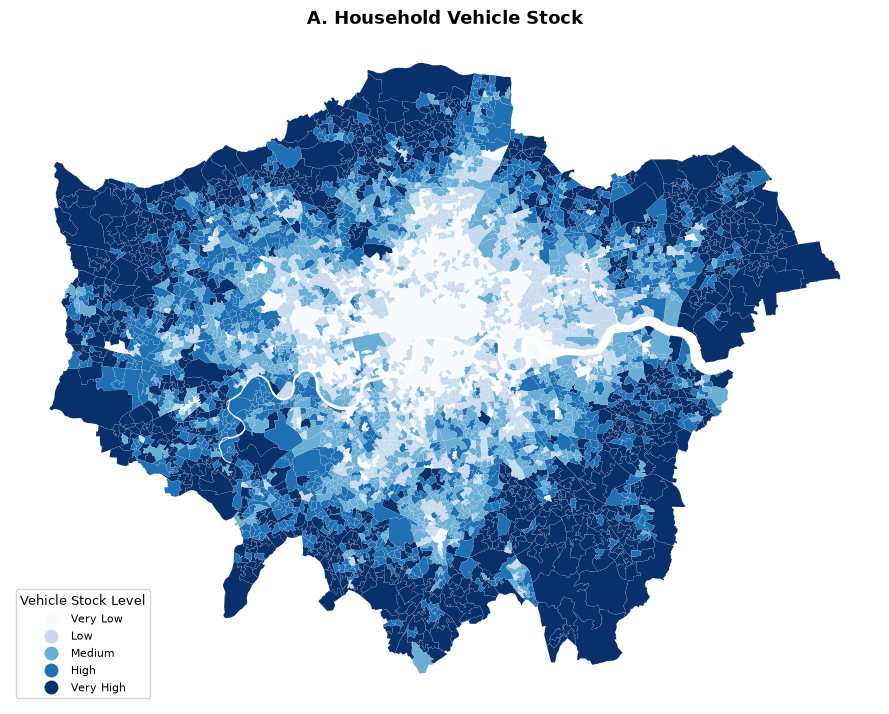

In [5]:
# Cell A
fig, ax = plt.subplots(figsize=(9, 9))
plot_quantile_choropleth(
    lsoa_gdf, "vehicle_stock_proxy", ax,
    title="A. Household Vehicle Stock",
    legend_title="Vehicle Stock Level",
    class_labels=["Very Low", "Low", "Medium", "High", "Very High"],
    cmap="Blues",
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_eda_A_vehicle_stock.png", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/ipykernel_46450/2980800691.py:65: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  work.loc[work["class_label"].isna()].plot(


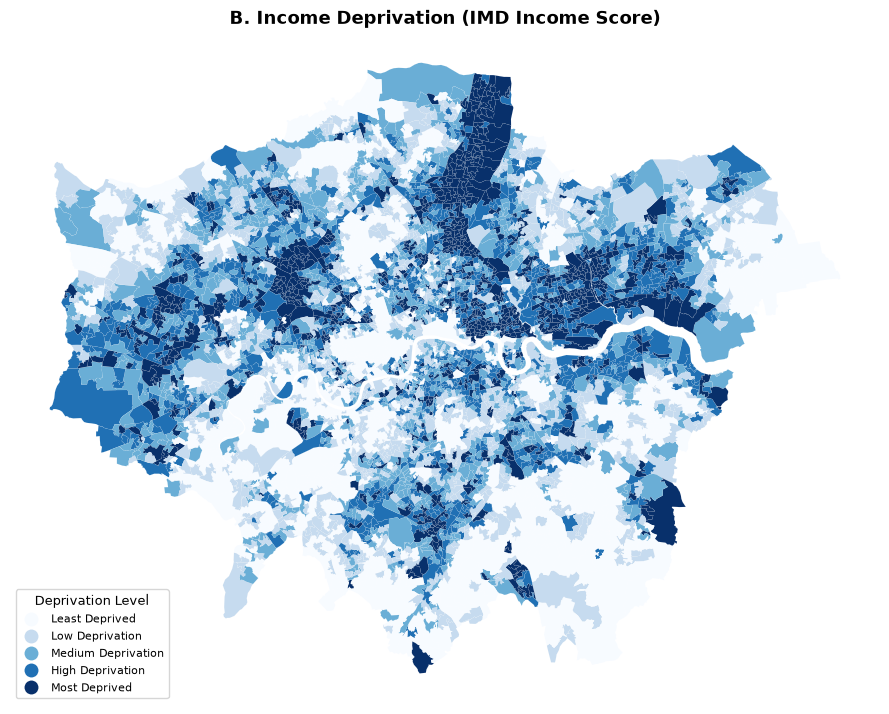

In [6]:
# Cell B
fig, ax = plt.subplots(figsize=(9, 9))
plot_quantile_choropleth(
    lsoa_gdf, "income_score", ax,
    title="B. Income Deprivation (IMD Income Score)",
    legend_title="Deprivation Level",
    class_labels=["Least Deprived", "Low Deprivation", "Medium Deprivation",
                  "High Deprivation", "Most Deprived"],
    cmap="Blues",
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_eda_B_income_score.png", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/ipykernel_46450/2980800691.py:31: UserWarning: Data produced only 4 distinct quantile bins (duplicate edges dropped); using the first 4 of the 5 labels supplied.
  warnings.warn(
/var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/ipykernel_46450/2980800691.py:65: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  work.loc[work["class_label"].isna()].plot(


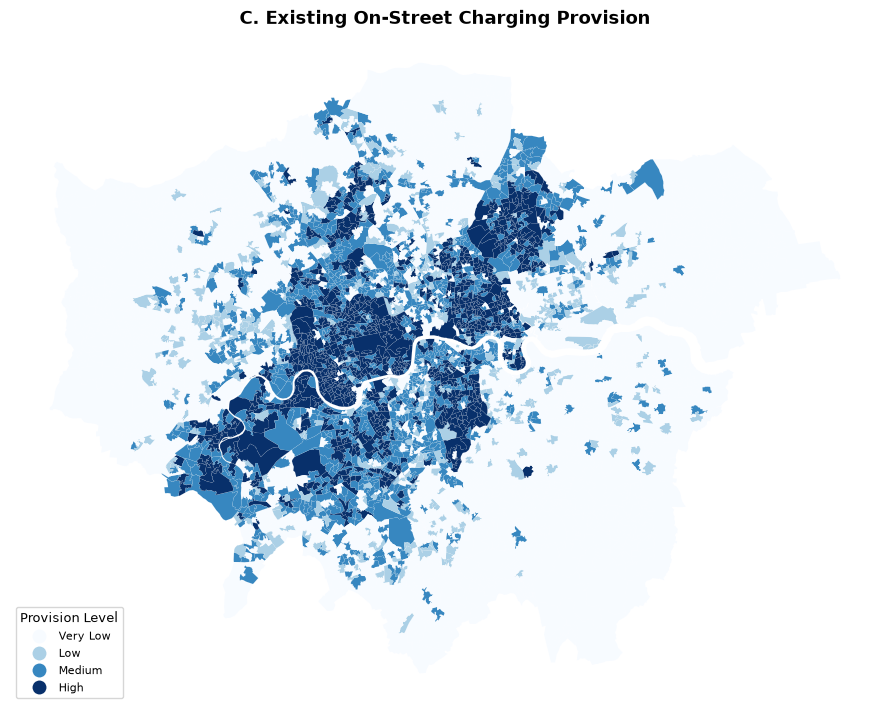

In [7]:
# Cell C
fig, ax = plt.subplots(figsize=(9, 9))
plot_quantile_choropleth(
    lsoa_gdf, "e_i", ax,
    title="C. Existing On-Street Charging Provision",
    legend_title="Provision Level",
    class_labels=["Very Low", "Low", "Medium", "High", "Very High"],
    cmap="Blues",
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_eda_C_existing_provision.png", dpi=300, bbox_inches="tight")
plt.show()


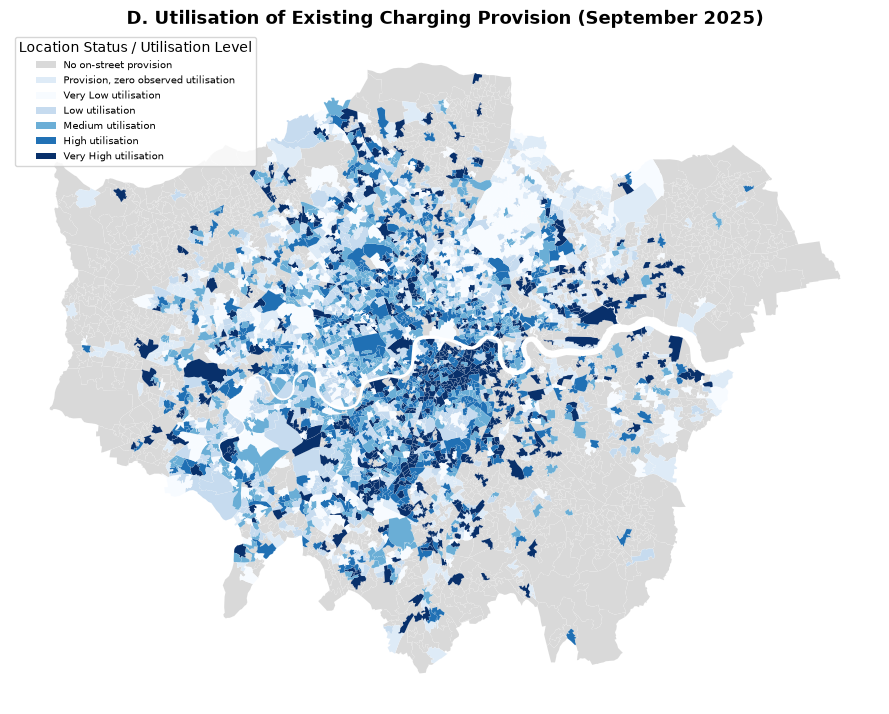

In [8]:
# Cell D
fig, ax = plt.subplots(figsize=(9, 9))
plot_utilisation_panel(lsoa_gdf, ax, cmap="Blues")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_eda_D_utilisation.png", dpi=300, bbox_inches="tight")
plt.show()


## 5. Optional preliminary comparison table

This is intentionally descriptive only.  
It is included to help narrate the figure rather than to make causal claims.


In [9]:
comparison_table = pd.DataFrame(
    {
        "indicator": [
            "Correlation: vehicle stock proxy vs e_i",
            "Correlation: income score vs e_i",
            "Correlation: income score vs U_i (where e_i > 0)",
        ],
        "value": [
            lsoa_gdf["vehicle_stock_proxy"].corr(lsoa_gdf["e_i"]),
            lsoa_gdf["income_score"].corr(lsoa_gdf["e_i"]),
            lsoa_gdf.loc[lsoa_gdf["has_evse_i"], "income_score"].corr(
                lsoa_gdf.loc[lsoa_gdf["has_evse_i"], "U_i"]
            ),
        ],
    }
)

display(comparison_table)


,indicator,value
0,Correlation: vehicle stock proxy vs e_i,-0.273807
1,Correlation: income score vs e_i,-0.088005
2,Correlation: income score vs U_i (where e_i > 0),0.080115


## 6. Suggested dissertation narrative

A concise interpretation could be written along the following lines:

- **Panel A** identifies the broad spatial base of potential household charging demand.
- **Panel B** introduces the equity dimension by showing where income deprivation is most concentrated.
- **Panel C** shows the current distribution of existing on-street charging provision.
- **Panel D** distinguishes between three policy-relevant situations:
  no provision, provision with no observed use, and provision with positive use.

Taken together, the figure suggests that London's existing on-street charging geography
does not automatically mirror either the household demand base or the equity pattern.
This visual diagnosis motivates the next stage of the dissertation, in which demand,
equity weighting and additional charging provision are formalised within the
allocation model.
